# Reproducing GGSS-R Image Reconstruction

This notebook attempts to reproduce the image-reconstruction pipeline from “Enhanced Privacy Leakage from Noise-Perturbed Gradients via Gradient-Guided Conditional Diffusion Models” using the authors' GGSS-R implementation.

The notebook is designed to run from top to bottom in a fresh environment.

### What is preserved from the authors' repository

- GGSS-R / GSS reconstruction logic
- the authors' `MLP_1` victim architecture
- the authors' FFHQ diffusion-model configuration
- the authors' reconstruction operator and conditioning method
- the authors' 1000-step DDIM configuration
- guidance rate `mr = 0.20`
- batch size 1 for gradient acquisition

### What is changed here

The authors' supplied repository does not contain the victim-model or diffusion-model checkpoints used in their experiments. Therefore:

1. `MLP_1` is trained locally for **one epoch** on CelebA using the `Smiling` attribute.
2. The FFHQ diffusion checkpoint is downloaded from a public mirror and verified by SHA-256.
3. Two small output-handling fixes are applied to the authors' code:
   - create the reconstruction progress directory before writing snapshots;
   - save sparse `x_t` and predicted `x_0` snapshots every 100 reverse-diffusion steps under the experiment output directory.
4. MSE, PSNR, and LPIPS are evaluated across the saved trajectory, and the reconstruction snapshots are displayed directly in the notebook.

The original authors' source files are otherwise left intact.

## 1. Project paths and reproducibility configuration

All paths are relative to the directory from which this notebook is launched. No `/content`, Google Drive, or other platform-specific path is used.

In [1]:
from pathlib import Path
import os
import sys
import json
import random
import hashlib
import shutil
import subprocess
import platform
import importlib.util

PROJECT_ROOT = Path(
    os.environ.get("GGSSR_PROJECT_ROOT", Path.cwd())
).resolve()

VENDOR_ROOT = PROJECT_ROOT / "vendor"
RESULTS_ROOT = PROJECT_ROOT / "results"
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"

VENDOR_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

SEED = 2026
TARGET_INDEX = 0

random.seed(SEED)

print("Project root :", PROJECT_ROOT)
print("Vendor root  :", VENDOR_ROOT)
print("Results root :", RESULTS_ROOT)
print("Artifacts    :", ARTIFACTS_ROOT)

Project root : /content
Vendor root  : /content/vendor
Results root : /content/results
Artifacts    : /content/artifacts


## 2. Dependencies and compute device

A CUDA GPU is recommended. The authors' runner can fall back to CPU, but the full 1000-step reconstruction is computationally demanding.

In [2]:
# PyTorch / torchvision are platform-specific and must already be installed.
for package in ("torch", "torchvision"):
    if importlib.util.find_spec(package) is None:
        raise RuntimeError(
            f"{package} is not installed. Install a PyTorch build appropriate "
            "for your operating system / CUDA version, then rerun this cell."
        )

required_packages = {
    "yaml": "pyyaml",
    "datasets": "datasets",
    "lpips": "lpips",
    "opacus": "opacus",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
    "tqdm": "tqdm",
}

missing = [
    pip_name
    for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.run(
        [sys.executable, "-m", "pip", "install", *missing],
        check=True,
    )

import numpy as np
import torch
import torchvision

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    DEVICE = torch.device("cuda:0")
else:
    DEVICE = torch.device("cpu")

print("Python        :", sys.version.split()[0])
print("Platform      :", platform.platform())
print("PyTorch       :", torch.__version__)
print("Torchvision   :", torchvision.__version__)
print("Device        :", DEVICE)

if DEVICE.type == "cuda":
    print("CUDA          :", torch.version.cuda)
    print("GPU           :", torch.cuda.get_device_name(0))
else:
    print(
        "\nWARNING: CUDA was not detected. The notebook remains runnable, "
        "but victim training and 1000-step GGSS-R reconstruction may be very slow."
    )

Installing missing packages: lpips, opacus
Python        : 3.13.15
Platform      : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch       : 2.11.0+cu128
Torchvision   : 0.26.0+cu128
Device        : cuda:0
CUDA          : 12.8
GPU           : Tesla T4


## 3. Obtain the authors' GGSS-R code

If a `code/` directory containing the authors' runner already exists beside the notebook, it is used directly. Otherwise, the public GGSS-R GitHub repository is cloned into `vendor/` and its bundled `code.zip` is extracted.

This makes the notebook usable both inside a GitHub project that already includes the authors' code and as a standalone downloaded notebook.

In [3]:
AUTHOR_REPO_URL = "https://github.com/mjyyhhxx/GGSS-R.git"

local_code = PROJECT_ROOT / "code"
vendored_code = VENDOR_ROOT / "ggssr_code"
author_git_root = VENDOR_ROOT / "GGSS-R"

if (local_code / "sample_condition_same_inputs.py").is_file():
    CODE_ROOT = local_code.resolve()
    print("Using existing project code directory:")
    print(CODE_ROOT)

elif (vendored_code / "sample_condition_same_inputs.py").is_file():
    CODE_ROOT = vendored_code.resolve()
    print("Using previously extracted authors' code:")
    print(CODE_ROOT)

else:
    if author_git_root.exists():
        shutil.rmtree(author_git_root)

    print("Cloning authors' GGSS-R repository...")
    subprocess.run(
        [
            "git", "clone",
            "--depth", "1",
            AUTHOR_REPO_URL,
            str(author_git_root),
        ],
        check=True,
    )

    code_zip = author_git_root / "code.zip"
    if not code_zip.is_file():
        raise FileNotFoundError(
            f"The cloned repository did not contain code.zip: {code_zip}"
        )

    if vendored_code.exists():
        shutil.rmtree(vendored_code)

    extraction_root = VENDOR_ROOT / "_ggssr_extract"
    if extraction_root.exists():
        shutil.rmtree(extraction_root)
    extraction_root.mkdir(parents=True)

    import zipfile
    with zipfile.ZipFile(code_zip, "r") as zf:
        zf.extractall(extraction_root)

    candidates = [
        extraction_root / "code",
        extraction_root,
    ]

    extracted_code = next(
        (
            p for p in candidates
            if (p / "sample_condition_same_inputs.py").is_file()
        ),
        None,
    )

    if extracted_code is None:
        raise RuntimeError(
            "Could not locate sample_condition_same_inputs.py "
            "after extracting the authors' code.zip."
        )

    shutil.move(str(extracted_code), str(vendored_code))
    shutil.rmtree(extraction_root, ignore_errors=True)

    CODE_ROOT = vendored_code.resolve()
    print("Authors' code extracted to:")
    print(CODE_ROOT)

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

required_repo_files = [
    "sample_condition_same_inputs.py",
    "guided_diffusion/condition_methods.py",
    "guided_diffusion/measurements.py",
    "guided_diffusion/gaussian_diffusion.py",
    "guided_diffusion/attacked_model.py",
    "configs/model_config.yaml",
    "configs/diffusion_ddim1000_config.yaml",
    "configs/reconstruction_config.yaml",
]

missing_repo_files = [
    rel for rel in required_repo_files
    if not (CODE_ROOT / rel).is_file()
]

if missing_repo_files:
    raise FileNotFoundError(
        "Missing expected authors' repository files:\n- "
        + "\n- ".join(missing_repo_files)
    )

print("\nRepository integrity check passed.")

Cloning authors' GGSS-R repository...
Authors' code extracted to:
/content/vendor/ggssr_code

Repository integrity check passed.


## 4. Download and verify the FFHQ diffusion checkpoint

The authors' code expects `models/ffhq_10m.pt`, but the checkpoint is not included in the supplied repository. This notebook downloads the same public mirror used in the original exploratory run and verifies its SHA-256 hash before use.

In [4]:
from urllib.request import urlopen

MODEL_DIR = CODE_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DIFFUSION_CHECKPOINT = MODEL_DIR / "ffhq_10m.pt"

DIFFUSION_URL = (
    "https://huggingface.co/danaroth/"
    "zhang-image-restoration/resolve/main/"
    "ffhq_10m.pt?download=true"
)

EXPECTED_SHA256 = (
    "81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa"
)

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

if not DIFFUSION_CHECKPOINT.is_file():
    print("Downloading FFHQ diffusion checkpoint...")
    tmp_path = DIFFUSION_CHECKPOINT.with_suffix(".pt.part")

    with urlopen(DIFFUSION_URL) as response, open(tmp_path, "wb") as out:
        shutil.copyfileobj(response, out)

    tmp_path.replace(DIFFUSION_CHECKPOINT)

size_mb = DIFFUSION_CHECKPOINT.stat().st_size / (1024 ** 2)
actual_sha256 = sha256_file(DIFFUSION_CHECKPOINT)

print(f"Checkpoint size : {size_mb:.1f} MB")
print("SHA-256        :", actual_sha256)

if size_mb < 300:
    raise RuntimeError("Diffusion checkpoint is unexpectedly small.")

if actual_sha256 != EXPECTED_SHA256:
    raise RuntimeError(
        "Diffusion checkpoint hash mismatch.\n"
        f"Expected: {EXPECTED_SHA256}\n"
        f"Actual:   {actual_sha256}"
    )

print("FFHQ diffusion checkpoint verified.")

Checkpoint size : 357.1 MB
SHA-256        : 81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa
FFHQ diffusion checkpoint verified.


## 5. Load CelebA and reproduce the authors' image preprocessing

The victim model is trained on CelebA's `Smiling` attribute. Images are transformed exactly as in the authors' runner:

`Resize((256, 256)) → ToTensor() → Normalize(mean=0.5, std=0.5)`

In [5]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

CELEBA_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5),
    ),
])

print("Loading CelebA training split...")
celeba_train = load_dataset(
    "flwrlabs/celeba",
    split="train",
)

print("Loading CelebA test split...")
celeba_test = load_dataset(
    "flwrlabs/celeba",
    split="test",
)

for split_name, split in [
    ("train", celeba_train),
    ("test", celeba_test),
]:
    if "Smiling" not in split.column_names:
        raise RuntimeError(
            f"CelebA {split_name} split does not contain the Smiling attribute."
        )

example_tensor = CELEBA_TRANSFORM(
    celeba_train[0]["image"]
)

assert example_tensor.shape == (3, 256, 256)

print("Training samples :", len(celeba_train))
print("Test samples     :", len(celeba_test))
print("Processed shape  :", tuple(example_tensor.shape))
print(
    "Processed range  :",
    float(example_tensor.min()),
    "to",
    float(example_tensor.max()),
)

Loading CelebA training split...


README.md:   0%|          | 0.00/9.28k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

img_align+identity+attr/train-00000-of-0(…): reconstructing file:   0%|          |  0.00B /  500MB            

...

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Loading CelebA test split...


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Training samples : 162770
Test samples     : 19962
Processed shape  : (3, 256, 256)
Processed range  : -1.0 to 1.0


## 6. Train or load the authors' `MLP_1` victim model

The authors provide the `MLP_1` architecture but not its trained checkpoint. If `model_state/MLP_1.pth` already exists, it is reused. Otherwise, the model is trained for one epoch on CelebA.

The exploratory run used:

- seed: 2026
- batch size: 64
- epochs: 1
- AdamW learning rate: `1e-4`
- weight decay: `1e-5`

`NUM_WORKERS = 0` is used here deliberately for cross-platform notebook compatibility.

In [6]:
import torch.nn as nn

CHECKPOINT_DIR = CODE_ROOT / "model_state"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
VICTIM_CHECKPOINT = CHECKPOINT_DIR / "MLP_1.pth"

BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 1
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
FORCE_RETRAIN = False

class CelebASmilingDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        image = self.transform(item["image"])
        label = torch.tensor(
            int(item["Smiling"]),
            dtype=torch.long,
        )
        return image, label

train_dataset = CelebASmilingDataset(
    celeba_train,
    CELEBA_TRANSFORM,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

from guided_diffusion.attacked_model import MLP_1

victim_model = MLP_1().to(DEVICE)
num_params = sum(p.numel() for p in victim_model.parameters())

print(f"Victim architecture : {type(victim_model).__name__}")
print(f"Parameters          : {num_params:,}")
print("Checkpoint          :", VICTIM_CHECKPOINT)

if VICTIM_CHECKPOINT.is_file() and not FORCE_RETRAIN:
    state = torch.load(
        VICTIM_CHECKPOINT,
        map_location=DEVICE,
    )
    victim_model.load_state_dict(state)
    print("\nExisting victim checkpoint loaded; training skipped.")

else:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        victim_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    victim_model.train()

    for epoch in range(EPOCHS):
        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\nEpoch {epoch + 1}/{EPOCHS}")

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(
                DEVICE,
                non_blocking=(DEVICE.type == "cuda"),
            )
            labels = labels.to(
                DEVICE,
                non_blocking=(DEVICE.type == "cuda"),
            )

            optimizer.zero_grad(set_to_none=True)
            outputs = victim_model(images)
            loss = criterion(outputs, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss at batch {batch_idx}: {loss.item()}"
                )

            loss.backward()
            optimizer.step()

            batch_n = labels.size(0)
            running_loss += loss.item() * batch_n
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += batch_n

            if (
                batch_idx == 0
                or (batch_idx + 1) % 250 == 0
                or (batch_idx + 1) == len(train_loader)
            ):
                print(
                    f"  batch {batch_idx + 1:5d}/{len(train_loader):5d} | "
                    f"loss {running_loss / total:.4f} | "
                    f"accuracy {100.0 * correct / total:.2f}%"
                )

    torch.save(
        victim_model.state_dict(),
        VICTIM_CHECKPOINT,
    )

    print("\nTraining complete.")
    print(f"Final training loss     : {running_loss / total:.6f}")
    print(f"Final training accuracy : {100.0 * correct / total:.2f}%")
    print("Checkpoint saved        :", VICTIM_CHECKPOINT)

Victim architecture : MLP_1
Parameters          : 100,729,730
Checkpoint          : /content/vendor/ggssr_code/model_state/MLP_1.pth

Epoch 1/1
  batch     1/ 2543 | loss 0.7042 | accuracy 39.06%
  batch   250/ 2543 | loss 0.4531 | accuracy 80.40%
  batch   500/ 2543 | loss 0.4025 | accuracy 82.68%
  batch   750/ 2543 | loss 0.3713 | accuracy 84.06%
  batch  1000/ 2543 | loss 0.3557 | accuracy 84.79%
  batch  1250/ 2543 | loss 0.3450 | accuracy 85.31%
  batch  1500/ 2543 | loss 0.3343 | accuracy 85.76%
  batch  1750/ 2543 | loss 0.3253 | accuracy 86.15%
  batch  2000/ 2543 | loss 0.3188 | accuracy 86.47%
  batch  2250/ 2543 | loss 0.3132 | accuracy 86.75%
  batch  2500/ 2543 | loss 0.3089 | accuracy 86.94%
  batch  2543/ 2543 | loss 0.3081 | accuracy 86.97%

Training complete.
Final training loss     : 0.308134
Final training accuracy : 86.97%
Checkpoint saved        : /content/vendor/ggssr_code/model_state/MLP_1.pth


## 7. Held-out victim-model sanity check

The checkpoint is evaluated on the CelebA test split before reconstruction. This checks that the locally trained victim is functional rather than attempting to reproduce the paper's reported attack result by assumption.

In [7]:
test_dataset = CelebASmilingDataset(
    celeba_test,
    CELEBA_TRANSFORM,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

victim_model = MLP_1().to(DEVICE)
victim_model.load_state_dict(
    torch.load(
        VICTIM_CHECKPOINT,
        map_location=DEVICE,
    )
)
victim_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            DEVICE,
            non_blocking=(DEVICE.type == "cuda"),
        )
        labels = labels.to(
            DEVICE,
            non_blocking=(DEVICE.type == "cuda"),
        )

        outputs = victim_model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100.0 * correct / total

print(f"Held-out test accuracy: {test_accuracy:.2f}%")

if test_accuracy <= 60.0:
    raise RuntimeError(
        "Victim model appears insufficiently trained. "
        "Do not proceed to reconstruction."
    )

print("Victim model passed the sanity check.")

Held-out test accuracy: 86.84%
Victim model passed the sanity check.


## 8. Select the held-out CelebA reconstruction target

The experiment uses `CelebA test[0]`, matching the original exploratory notebook. The original RGB image is saved; the authors' runner performs its own resize and normalization when loading it.

The target metadata is also written to JSON for reproducibility.

CelebA test index : 0
Original size     : (178, 218)
Smiling           : True
Attack shape      : (1, 3, 256, 256)
Saved target      : /content/vendor/ggssr_code/data/samples/celeba_target/target_0000.png
Saved metadata    : /content/artifacts/target_0000_metadata.json


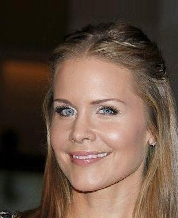

In [8]:
from PIL import Image
from IPython.display import display

TARGET_DIR = (
    CODE_ROOT
    / "data"
    / "samples"
    / "celeba_target"
)
TARGET_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PATH = TARGET_DIR / "target_0000.png"
TARGET_METADATA_PATH = ARTIFACTS_ROOT / "target_0000_metadata.json"

target_item = celeba_test[TARGET_INDEX]
target_image = target_item["image"].convert("RGB")
target_smiling = bool(target_item["Smiling"])

target_image.save(
    TARGET_PATH,
    format="PNG",
)

target_metadata = {
    "dataset": "flwrlabs/celeba",
    "split": "test",
    "target_index": int(TARGET_INDEX),
    "filename": TARGET_PATH.name,
    "original_size": list(target_image.size),
    "original_mode": target_image.mode,
    "smiling": target_smiling,
    "preprocessing": (
        "Resize((256,256)) -> ToTensor() -> "
        "Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))"
    ),
}

TARGET_METADATA_PATH.write_text(
    json.dumps(target_metadata, indent=2)
)

target_tensor = CELEBA_TRANSFORM(
    target_image
).unsqueeze(0).to(DEVICE)

print("CelebA test index :", TARGET_INDEX)
print("Original size     :", target_image.size)
print("Smiling           :", target_smiling)
print("Attack shape      :", tuple(target_tensor.shape))
print("Saved target      :", TARGET_PATH)
print("Saved metadata    :", TARGET_METADATA_PATH)

display(target_image)

## 9. Apply minimal output-handling patches

The following cell makes two narrowly scoped changes to a fresh copy of the authors' code:

1. creates the `progresss/<image_id>/` directory before the sampler writes into it;
2. saves `x_t` and predicted `x_0` snapshots only every 100 timesteps (plus `t=0`) and places both under the current experiment's output tree.

No conditioning, gradient, diffusion, victim-model, measurement, or optimization equation is changed.

In [9]:
RUNNER_PATH = CODE_ROOT / "sample_condition_same_inputs.py"
GD_PATH = CODE_ROOT / "guided_diffusion" / "gaussian_diffusion.py"

# ------------------------------------------------------------
# Patch 1: ensure the runner creates the directory it passes
# as save_root. The authors' source uses "progresss" here.
# ------------------------------------------------------------

runner_original = """        sample, distance_list = sample_fn(x_start=x_start, measurement=y_n, record=True,
                                          save_root=os.path.join(out_path, 'progresss', str(i).zfill(5)))"""

runner_patched = """        progress_dir = os.path.join(
            out_path,
            'progresss',
            str(i).zfill(5)
        )
        os.makedirs(progress_dir, exist_ok=True)

        sample, distance_list = sample_fn(
            x_start=x_start,
            measurement=y_n,
            record=True,
            save_root=progress_dir
        )"""

runner_text = RUNNER_PATH.read_text()

if runner_patched in runner_text:
    print("Runner directory patch already present.")
elif runner_original in runner_text:
    RUNNER_PATH.write_text(
        runner_text.replace(
            runner_original,
            runner_patched,
            1,
        )
    )
    print("Runner directory patch applied.")
else:
    raise RuntimeError(
        "Expected runner block was not found. "
        "Refusing to modify an unexpected source version."
    )

# ------------------------------------------------------------
# Patch 2: sparse trajectory saving and experiment-local x0 path.
# This handles a fresh authors' file directly.
# ------------------------------------------------------------

gd_original = """            if record:
                file_path = os.path.join(save_root, f"x_{str(idx).zfill(4)}.png")
                x0_file_path = os.path.join('code/results/reconstruction/progress/x0', f"x_{str(idx).zfill(4)}.png")
                plt.imsave(file_path, clear_color(img))
                plt.imsave(x0_file_path, clear_color(out['pred_xstart']) )"""

gd_patched = """            # Save sparse reconstruction trajectory snapshots.
            if record and (idx % 100 == 0 or idx == 0):
                file_path = os.path.join(
                    save_root,
                    f"x_{str(idx).zfill(4)}.png"
                )

                x0_file_path = os.path.join(
                    save_root,
                    "x0",
                    f"x_{str(idx).zfill(4)}.png"
                )

                os.makedirs(
                    os.path.dirname(x0_file_path),
                    exist_ok=True
                )

                plt.imsave(
                    file_path,
                    clear_color(img)
                )

                plt.imsave(
                    x0_file_path,
                    clear_color(out['pred_xstart'])
                )"""

gd_text = GD_PATH.read_text()

if gd_patched in gd_text:
    print("Sparse trajectory patch already present.")
elif gd_original in gd_text:
    GD_PATH.write_text(
        gd_text.replace(
            gd_original,
            gd_patched,
            1,
        )
    )
    print("Sparse trajectory patch applied.")
else:
    raise RuntimeError(
        "Expected gaussian_diffusion.py save block was not found. "
        "Refusing to modify an unexpected source version."
    )

# ------------------------------------------------------------
# Verify both changes.
# ------------------------------------------------------------

runner_verify = RUNNER_PATH.read_text()
gd_verify = GD_PATH.read_text()

assert "os.makedirs(progress_dir, exist_ok=True)" in runner_verify
assert "save_root=progress_dir" in runner_verify
assert "if record and (idx % 100 == 0 or idx == 0):" in gd_verify
assert 'save_root,\n                    "x0",' in gd_verify

print("\nPatch verification passed.")
print("Modified only:")
print(" -", RUNNER_PATH.relative_to(PROJECT_ROOT) if RUNNER_PATH.is_relative_to(PROJECT_ROOT) else RUNNER_PATH)
print(" -", GD_PATH.relative_to(PROJECT_ROOT) if GD_PATH.is_relative_to(PROJECT_ROOT) else GD_PATH)

Runner directory patch applied.
Sparse trajectory patch applied.

Patch verification passed.
Modified only:
 - vendor/ggssr_code/sample_condition_same_inputs.py
 - vendor/ggssr_code/guided_diffusion/gaussian_diffusion.py


## 10. Record the experiment configuration

This produces a machine-readable description of the run, including checkpoint hashes and software versions.

In [10]:
import importlib.metadata as importlib_metadata

BASELINE_ROOT = (
    RESULTS_ROOT
    / "baseline_fixed_mr"
).resolve()
BASELINE_ROOT.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = BASELINE_ROOT / "run_config.json"

def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return None

def git_commit(path):
    try:
        result = subprocess.run(
            ["git", "-C", str(path), "rev-parse", "HEAD"],
            check=True,
            capture_output=True,
            text=True,
        )
        return result.stdout.strip()
    except Exception:
        return None

run_config = {
    "seed": SEED,
    "dataset": "flwrlabs/celeba",
    "victim_architecture": "MLP_1",
    "victim_training": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "test_accuracy_percent": test_accuracy,
    },
    "target": {
        "split": "test",
        "index": TARGET_INDEX,
        "smiling": target_smiling,
        "path": str(TARGET_PATH.relative_to(PROJECT_ROOT))
        if TARGET_PATH.is_relative_to(PROJECT_ROOT)
        else str(TARGET_PATH),
    },
    "attack": {
        "method": "GSS",
        "guidance_scale": 0.20,
        "interval": 1,
        "diffusion_config": "configs/diffusion_ddim1000_config.yaml",
        "task_config": "configs/reconstruction_config.yaml",
        "gradient_noise_used_by_runner": "none (y_n = y in authors' runner)",
    },
    "checkpoints": {
        "victim_path": str(VICTIM_CHECKPOINT),
        "victim_sha256": sha256_file(VICTIM_CHECKPOINT),
        "diffusion_path": str(DIFFUSION_CHECKPOINT),
        "diffusion_sha256": sha256_file(DIFFUSION_CHECKPOINT),
    },
    "environment": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(DEVICE),
        "datasets": package_version("datasets"),
        "lpips": package_version("lpips"),
        "opacus": package_version("opacus"),
    },
    "authors_repo_commit": git_commit(
        AUTHOR_REPO_URL if False else author_git_root
    ) if author_git_root.exists() else None,
}

RUN_CONFIG_PATH.write_text(
    json.dumps(run_config, indent=2)
)

print(json.dumps(run_config, indent=2))
print("\nRun configuration saved to:")
print(RUN_CONFIG_PATH)

{
  "seed": 2026,
  "dataset": "flwrlabs/celeba",
  "victim_architecture": "MLP_1",
  "victim_training": {
    "epochs": 1,
    "batch_size": 64,
    "learning_rate": 0.0001,
    "weight_decay": 1e-05,
    "test_accuracy_percent": 86.83999599238554
  },
  "target": {
    "split": "test",
    "index": 0,
    "smiling": true,
    "path": "vendor/ggssr_code/data/samples/celeba_target/target_0000.png"
  },
  "attack": {
    "method": "GSS",
    "guidance_scale": 0.2,
    "interval": 1,
    "diffusion_config": "configs/diffusion_ddim1000_config.yaml",
    "task_config": "configs/reconstruction_config.yaml",
    "gradient_noise_used_by_runner": "none (y_n = y in authors' runner)"
  },
  "checkpoints": {
    "victim_path": "/content/vendor/ggssr_code/model_state/MLP_1.pth",
    "victim_sha256": "8bad46385d5210f78cd48d826a398a5e5a59f2295b8ab424d19405c40687c9e8",
    "diffusion_path": "/content/vendor/ggssr_code/models/ffhq_10m.pt",
    "diffusion_sha256": "81d535743156ec6be34d8668e6920da94f061

## 11. Run the GGSS-R baseline reconstruction

The authors' runner is invoked as a subprocess from the authors' code directory so that its relative checkpoint paths continue to resolve exactly as intended.

The original repository prints tensor shapes and scalar tensors on every conditioning step. Rather than modifying `condition_methods.py`, this notebook simply suppresses lines containing those debug prints while streaming the subprocess output. Errors, tracebacks, logger messages, and other output remain visible.

In [11]:
# Remove only the previous run output, not checkpoints or data.
if BASELINE_ROOT.exists():
    shutil.rmtree(BASELINE_ROOT)
BASELINE_ROOT.mkdir(parents=True, exist_ok=True)

required_files = [
    CODE_ROOT / "sample_condition_same_inputs.py",
    CODE_ROOT / "guided_diffusion" / "gaussian_diffusion.py",
    CODE_ROOT / "configs" / "model_config.yaml",
    CODE_ROOT / "configs" / "diffusion_ddim1000_config.yaml",
    CODE_ROOT / "configs" / "reconstruction_config.yaml",
    DIFFUSION_CHECKPOINT,
    VICTIM_CHECKPOINT,
    TARGET_PATH,
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

cmd = [
    sys.executable,
    "sample_condition_same_inputs.py",
    "--model_config", "configs/model_config.yaml",
    "--diffusion_config", "configs/diffusion_ddim1000_config.yaml",
    "--task_config", "configs/reconstruction_config.yaml",
    "--gpu", "0",
    "--interval", "1",
    "--save_dir", str(BASELINE_ROOT),
    "--method", "GSS",
    "--data_root", "data/samples/celeba_target/",
    "--guidance_scale", "0.2",
]

print("Attack method   : GSS")
print("Guidance rate   : 0.20")
print("Diffusion steps : 1000")
print("Gradient noise  : none")
print("Victim          : MLP_1")
print("Target          : CelebA test[0]")
print("Output          :", BASELINE_ROOT)
print("\nCommand:")
print(" ".join(cmd))
print("\nStarting GGSS-R...\n")

process = subprocess.Popen(
    cmd,
    cwd=str(CODE_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

def is_noisy_debug_line(line):
    stripped = line.strip()

    # These are the three per-step prints in the authors' GSS
    # conditioning code: difference.shape, grad.shape, sigma_t.
    return (
        "torch.Size(" in stripped
        or stripped.startswith("tensor(")
    )

try:
    for line in iter(process.stdout.readline, ""):
        if is_noisy_debug_line(line):
            continue
        print(line, end="", flush=True)
finally:
    if process.stdout is not None:
        process.stdout.close()

return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"GGSS-R exited with return code {return_code}."
    )

print("\nGGSS-R baseline completed.")
print("Results:", BASELINE_ROOT)

Attack method   : GSS
Guidance rate   : 0.20
Diffusion steps : 1000
Gradient noise  : none
Victim          : MLP_1
Target          : CelebA test[0]
Output          : /content/results/baseline_fixed_mr

Command:
/usr/bin/python3 sample_condition_same_inputs.py --model_config configs/model_config.yaml --diffusion_config configs/diffusion_ddim1000_config.yaml --task_config configs/reconstruction_config.yaml --gpu 0 --interval 1 --save_dir /content/results/baseline_fixed_mr --method GSS --data_root data/samples/celeba_target/ --guidance_scale 0.2

Starting GGSS-R...

2026-09-02 06:47:13,530 [DPS] >> Device set to cuda:0.
09/02/2026 06:47:13:INFO:Device set to cuda:0.
2026-09-02 06:47:16,098 [DPS] >> Operation: reconstruction / Noise: gaussian
09/02/2026 06:47:16:INFO:Operation: reconstruction / Noise: gaussian
2026-09-02 06:47:16,101 [DPS] >> Conditioning method : GSS
09/02/2026 06:47:16:INFO:Conditioning method : GSS
2026-09-02 06:47:16,137 [DPS] >> Inference for image 0
09/02/2026 06:47:

## 12. Inspect the reconstruction trajectory

For a 1000-step run, the sparse-saving patch produces predicted `x_0` snapshots at timesteps `900, 800, ..., 100, 0`. They are shown below alongside the target so the reconstruction can be inspected directly from the rendered notebook.

Saved x_t snapshots : 10
Saved x0 snapshots  : 10
Timesteps           : [900, 800, 700, 600, 500, 400, 300, 200, 100, 0]


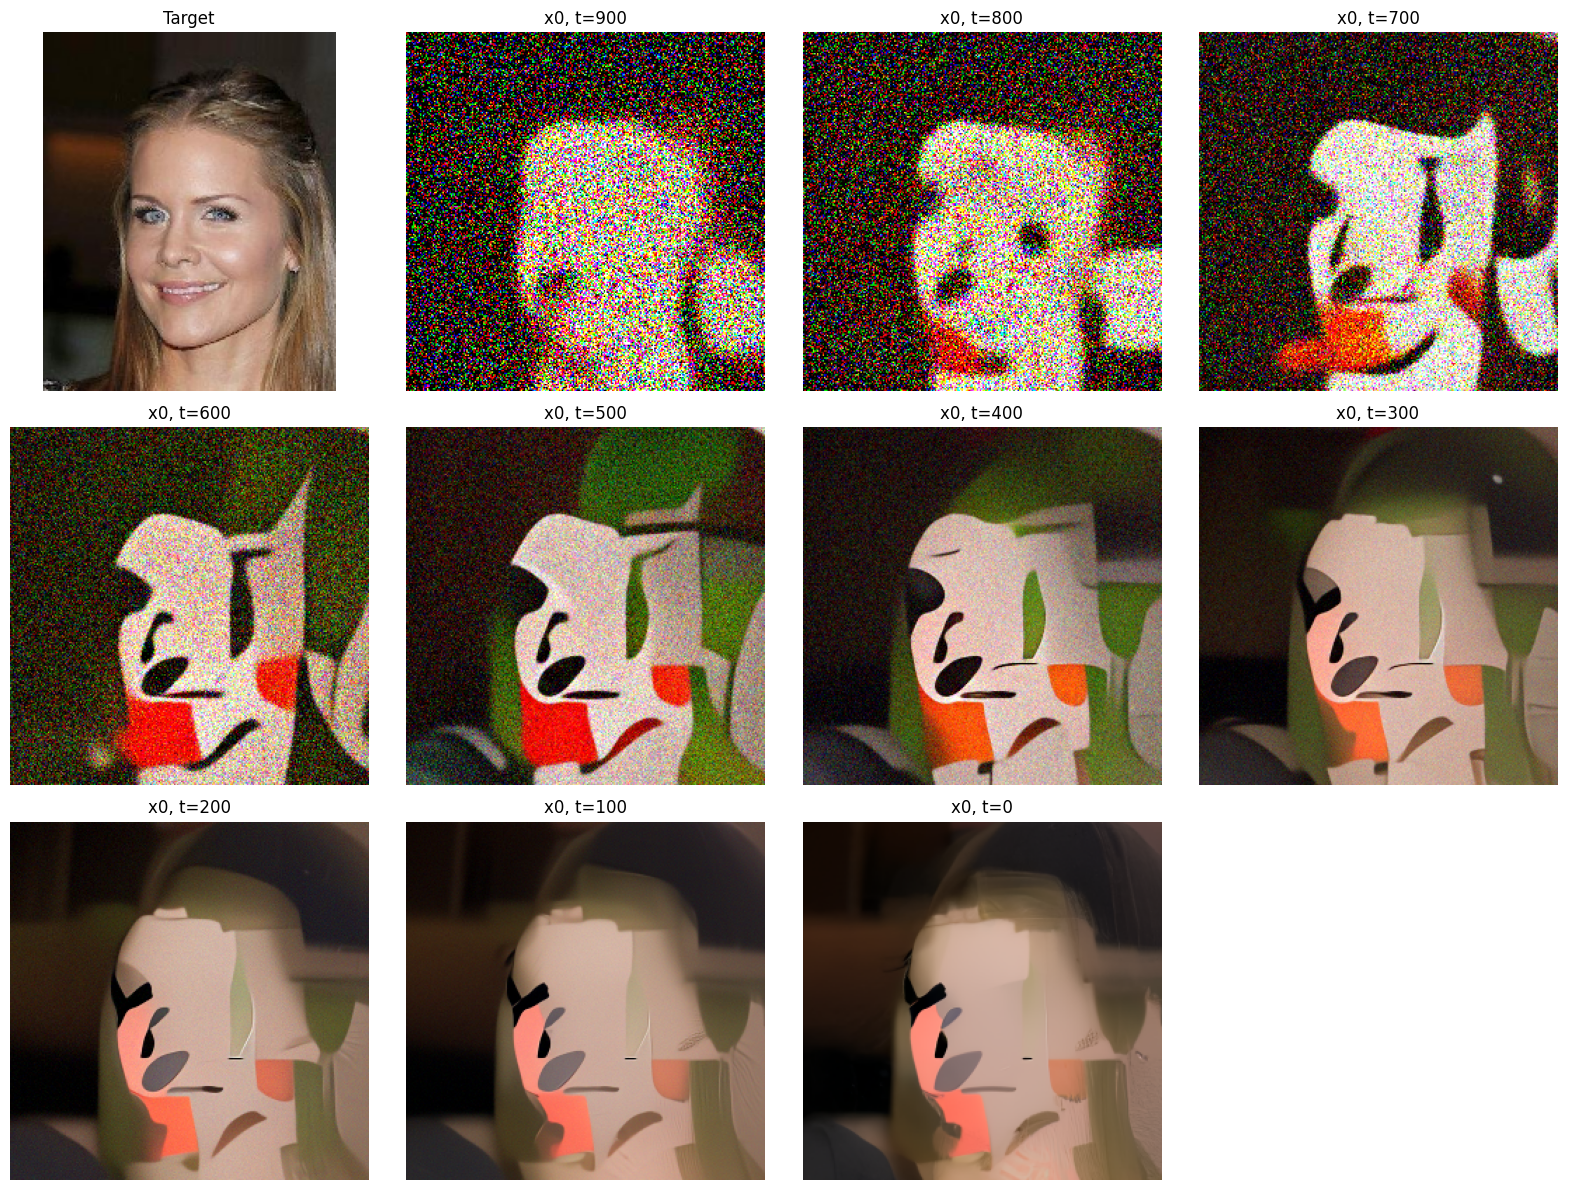

Saved reconstruction grid: /content/results/baseline_fixed_mr/reconstruction_grid.png


In [12]:
import matplotlib.pyplot as plt

PROGRESS_ROOT = (
    BASELINE_ROOT
    / "reconstruction"
    / "progresss"
    / "00000"
)
X_ROOT = PROGRESS_ROOT
X0_ROOT = PROGRESS_ROOT / "x0"

if not X_ROOT.is_dir():
    raise FileNotFoundError(
        f"Reconstruction progress directory not found: {X_ROOT}"
    )

def discover_snapshots(root):
    snapshots = {}
    for path in sorted(root.glob("x_*.png")):
        try:
            timestep = int(path.stem.split("_")[1])
        except (IndexError, ValueError):
            continue
        snapshots[timestep] = path
    return snapshots

x_snapshots = discover_snapshots(X_ROOT)
x0_snapshots = discover_snapshots(X0_ROOT)

common_timesteps = sorted(
    set(x_snapshots) & set(x0_snapshots),
    reverse=True,
)

print("Saved x_t snapshots :", len(x_snapshots))
print("Saved x0 snapshots  :", len(x0_snapshots))
print("Timesteps           :", common_timesteps)

if not common_timesteps:
    raise RuntimeError("No common x_t / x0 snapshots were found.")

images = [("Target", target_image)]
for timestep in common_timesteps:
    img = Image.open(x0_snapshots[timestep]).convert("RGB")
    images.append((f"x0, t={timestep}", img))

ncols = 4
nrows = int(np.ceil(len(images) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 4 * nrows),
)

axes = np.array(axes).reshape(-1)

for ax, (title, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

for ax in axes[len(images):]:
    ax.axis("off")

fig.tight_layout()

GRID_PATH = BASELINE_ROOT / "reconstruction_grid.png"
fig.savefig(
    GRID_PATH,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Saved reconstruction grid:", GRID_PATH)

## 13. Quantitative evaluation: MSE, PSNR, and LPIPS

The target is resized to `256 × 256`, matching the authors' runner. MSE and PSNR operate on `[0, 1]` tensors; LPIPS receives the corresponding `[-1, 1]` tensors.

Both noisy reverse-diffusion state `x_t` and predicted clean image `x_0` are evaluated at every saved timestep.

In [13]:
import math
import pandas as pd
import torch.nn.functional as F

import lpips

EVAL_ROOT = BASELINE_ROOT / "evaluation"
EVAL_ROOT.mkdir(parents=True, exist_ok=True)

METRICS_CSV = EVAL_ROOT / "metrics.csv"

target_resized = transforms.Resize(
    (256, 256)
)(target_image)

target_01 = (
    transforms.ToTensor()(target_resized)
    .unsqueeze(0)
    .to(DEVICE)
)

lpips_model = lpips.LPIPS(
    net="alex"
).to(DEVICE)
lpips_model.eval()

def load_snapshot(path):
    image = Image.open(path).convert("RGB")
    image = image.resize(
        (256, 256),
        Image.Resampling.BILINEAR,
    )
    tensor = transforms.ToTensor()(image)
    return tensor.unsqueeze(0).to(DEVICE)

def compute_metrics(image_01, target_01):
    mse = F.mse_loss(
        image_01,
        target_01,
    ).item()

    psnr = (
        float("inf")
        if mse == 0
        else 10.0 * math.log10(1.0 / mse)
    )

    image_lpips = image_01 * 2.0 - 1.0
    target_lpips = target_01 * 2.0 - 1.0

    with torch.no_grad():
        lpips_value = lpips_model(
            image_lpips,
            target_lpips,
        ).mean().item()

    return mse, psnr, lpips_value

rows = []

for timestep in common_timesteps:
    x_img = load_snapshot(
        x_snapshots[timestep]
    )
    x0_img = load_snapshot(
        x0_snapshots[timestep]
    )

    x_mse, x_psnr, x_lpips = compute_metrics(
        x_img,
        target_01,
    )
    x0_mse, x0_psnr, x0_lpips = compute_metrics(
        x0_img,
        target_01,
    )

    rows.append({
        "timestep": timestep,
        "x_mse": x_mse,
        "x_psnr": x_psnr,
        "x_lpips": x_lpips,
        "x0_mse": x0_mse,
        "x0_psnr": x0_psnr,
        "x0_lpips": x0_lpips,
    })

df = (
    pd.DataFrame(rows)
    .sort_values("timestep")
    .reset_index(drop=True)
)

df.to_csv(
    METRICS_CSV,
    index=False,
)

display(df)

best_x0_mse = df.loc[df["x0_mse"].idxmin()]
best_x0_psnr = df.loc[df["x0_psnr"].idxmax()]
best_x0_lpips = df.loc[df["x0_lpips"].idxmin()]

print("\nBest predicted x0 reconstruction:")
print(
    f"MSE   : t={int(best_x0_mse.timestep)}, "
    f"{best_x0_mse.x0_mse:.6e}"
)
print(
    f"PSNR  : t={int(best_x0_psnr.timestep)}, "
    f"{best_x0_psnr.x0_psnr:.4f} dB"
)
print(
    f"LPIPS : t={int(best_x0_lpips.timestep)}, "
    f"{best_x0_lpips.x0_lpips:.6e}"
)
print("\nMetrics CSV:", METRICS_CSV)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 162MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


,timestep,x_mse,x_psnr,x_lpips,x0_mse,x0_psnr,x0_lpips
0,0,0.006668,21.759797,0.456000,0.006668,21.759797,0.456000
1,100,0.035035,14.554963,1.025080,0.007662,21.156795,0.486350
2,200,0.063146,11.996574,1.145326,0.009512,20.217347,0.522743
3,300,0.089788,10.467796,1.190065,0.013946,18.555528,0.619811
4,400,0.090740,10.421992,1.213472,0.026529,15.762770,0.757111
5,500,0.107404,9.689801,1.225544,0.042592,13.706747,0.865555
6,600,0.105016,9.787433,1.223040,0.062819,12.019078,1.027355
7,700,0.099351,10.028294,1.232328,0.098464,10.067206,1.158175
8,800,0.101285,9.944563,1.260639,0.137857,8.605721,1.371840
9,900,0.098802,10.052321,1.237752,0.166868,7.776271,1.409841



Best predicted x0 reconstruction:
MSE   : t=0, 6.668379e-03
PSNR  : t=0, 21.7598 dB
LPIPS : t=0, 4.560001e-01

Metrics CSV: /content/results/baseline_fixed_mr/evaluation/metrics.csv


## 14. Metric trajectories

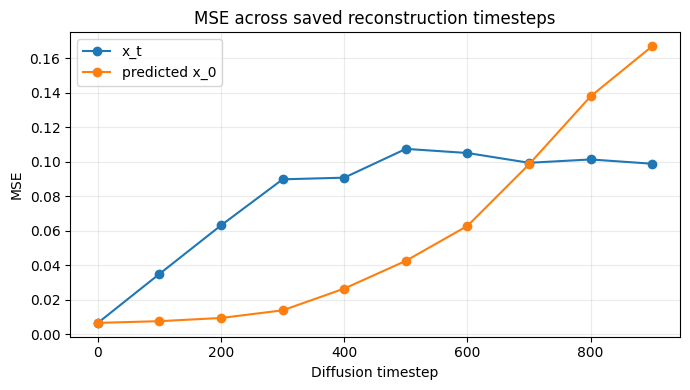

In [14]:
# MSE trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_mse"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_mse"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("MSE")
ax.set_title("MSE across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

MSE_PLOT = EVAL_ROOT / "mse_trajectory.png"
fig.savefig(MSE_PLOT, dpi=160, bbox_inches="tight")
plt.show()

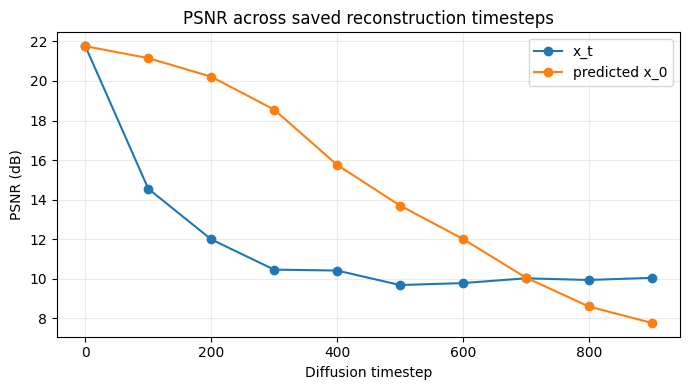

In [15]:
# PSNR trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_psnr"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_psnr"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

PSNR_PLOT = EVAL_ROOT / "psnr_trajectory.png"
fig.savefig(PSNR_PLOT, dpi=160, bbox_inches="tight")
plt.show()

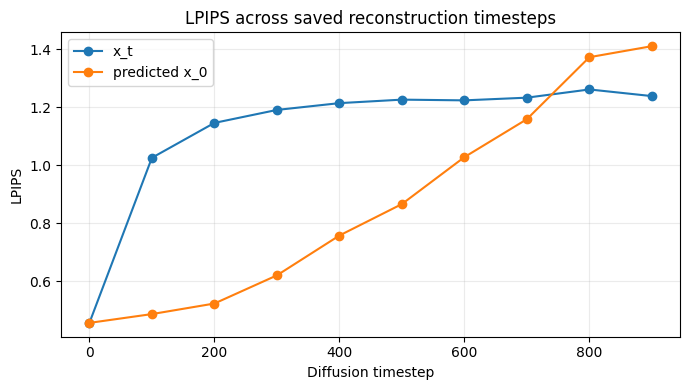

In [16]:
# LPIPS trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_lpips"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_lpips"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("LPIPS")
ax.set_title("LPIPS across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

LPIPS_PLOT = EVAL_ROOT / "lpips_trajectory.png"
fig.savefig(LPIPS_PLOT, dpi=160, bbox_inches="tight")
plt.show()

## 15. Export compact experiment artifacts

The final cell copies the target and final reconstruction into the run directory and refreshes `run_config.json` so the result folder can be committed or attached to a GitHub release independently of notebook outputs.

In [17]:
FINAL_RECON_SOURCE = (
    BASELINE_ROOT
    / "reconstruction"
    / "recon"
    / "00000.png"
)

if not FINAL_RECON_SOURCE.is_file():
    raise FileNotFoundError(
        f"Final reconstruction was not found: {FINAL_RECON_SOURCE}"
    )

TARGET_EXPORT = BASELINE_ROOT / "target.png"
FINAL_RECON_EXPORT = BASELINE_ROOT / "final_reconstruction.png"

shutil.copy2(
    TARGET_PATH,
    TARGET_EXPORT,
)
shutil.copy2(
    FINAL_RECON_SOURCE,
    FINAL_RECON_EXPORT,
)

run_config["results"] = {
    "metrics_csv": str(METRICS_CSV),
    "reconstruction_grid": str(GRID_PATH),
    "target": str(TARGET_EXPORT),
    "final_reconstruction": str(FINAL_RECON_EXPORT),
    "best_x0_mse": {
        "timestep": int(best_x0_mse.timestep),
        "value": float(best_x0_mse.x0_mse),
    },
    "best_x0_psnr": {
        "timestep": int(best_x0_psnr.timestep),
        "value": float(best_x0_psnr.x0_psnr),
    },
    "best_x0_lpips": {
        "timestep": int(best_x0_lpips.timestep),
        "value": float(best_x0_lpips.x0_lpips),
    },
}

RUN_CONFIG_PATH.write_text(
    json.dumps(run_config, indent=2)
)

print("Experiment artifacts:")
for path in [
    TARGET_EXPORT,
    FINAL_RECON_EXPORT,
    GRID_PATH,
    METRICS_CSV,
    MSE_PLOT,
    PSNR_PLOT,
    LPIPS_PLOT,
    RUN_CONFIG_PATH,
]:
    print(" -", path)

Experiment artifacts:
 - /content/results/baseline_fixed_mr/target.png
 - /content/results/baseline_fixed_mr/final_reconstruction.png
 - /content/results/baseline_fixed_mr/reconstruction_grid.png
 - /content/results/baseline_fixed_mr/evaluation/metrics.csv
 - /content/results/baseline_fixed_mr/evaluation/mse_trajectory.png
 - /content/results/baseline_fixed_mr/evaluation/psnr_trajectory.png
 - /content/results/baseline_fixed_mr/evaluation/lpips_trajectory.png
 - /content/results/baseline_fixed_mr/run_config.json


## Notes on reproducibility

- The locally trained victim checkpoint can be large because `MLP_1` has roughly 100 million parameters.
- The FFHQ diffusion checkpoint is also large and is therefore downloaded and hash-verified rather than provided as a checkpoint file.
- The notebook intentionally leaves the authors' attack implementation intact apart from the two output-path / sparse-saving changes described above.

In [18]:
import shutil
from pathlib import Path

results_dir = Path("results/baseline_fixed_mr")
shutil.make_archive(
    "baseline_fixed_mr",
    "zip",
    root_dir=results_dir.parent,
    base_dir=results_dir.name,
)

print("Created: baseline_fixed_mr.zip")

Created: baseline_fixed_mr.zip
